<a href="https://colab.research.google.com/github/rodrigocastillo69/Deep-learning-Vision/blob/main/Unidad1/Pr%C3%A1ctica%203/%20Lab1_3_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Deep Learning para visión de computadoras
##Lab 1.3 Arquitecturas CNN de referencia: LeNet-5, AlexNet, GoogLeNet y VGG16

**Unidad 1.** Fundamentos de visión por computadora y redes convolucionales
**1.3** Arquitecturas CNN para clasificación

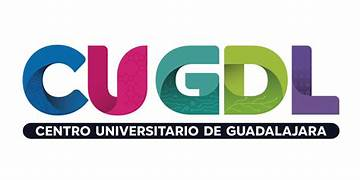

Esta práctica toma como referencia *"Arquitecturas de Redes Convolucionales"* (LeNet-5, AlexNet, GoogLeNet, VGG16), parte A definicion original de los modelos y parte B entrenamiento y evalúación sobre CIFAR-10, para poder comparar capacidad, número de parámetros, tiempo de entrenamiento y desempeño real.

**Objetivos de la práctica**
1. Implementar en PyTorch cuatro arquitecturas CNN clásicas adaptadas a CIFAR-10.
2. Entrenar y evaluar cada una bajo las mismas condiciones (mismos datos, épocas, optimizador).
3. Comparar número de parámetros, tiempo de entrenamiento y accuracy de test.
4. Discutir la relación entre profundidad/capacidad del modelo y su desempeño/eficiencia.

#PARTE A
### Arquitecturas de Redes Convolucionales
En el campo del deep learning y computer vision, una de estas competiciones, que hoy en día ya es un benchmark establecido, es la clasificación de imágenes en el dataset Imagenet. En 2012, la primera red neuronal convolucional entró en esta competición consiguiendo una mejora de 10 puntos sobre la mejor solución hasta la fecha, lo cual supuso un detonante para el campo del deep learning.

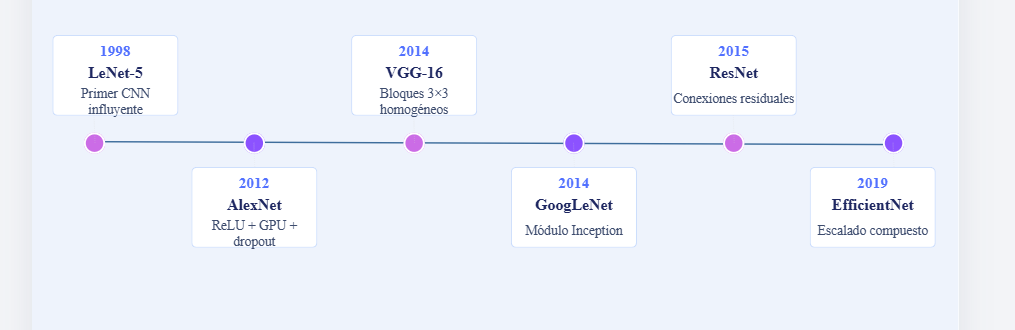

## LeNet-5

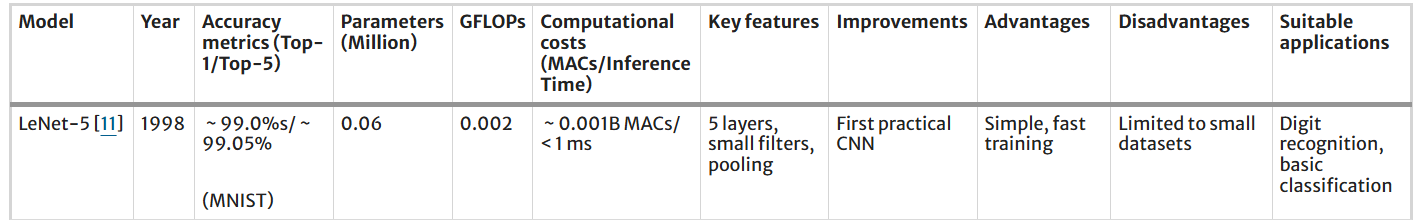

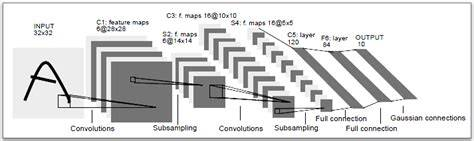

Esta `CNN` es alimentada por imágenes de 32x32 píxeles de dígitos manuscritos, y está formada por tres capas convolucionales, dos de las cuales reducen la dimensionalidad de los mapas de características mediante *average pooling*. La salida de la última capa convolucional es conectada un perceptrón multicapa de dos capas, que tienen la responsabilidad de dar la predicción final. [Artículo de publicación original](http://yann.lecun.com/exdb/publis/pdf/lecun-01a.pdf) . A continuación puedes ver un ejemplo de implementación en `Pytorch`.

In [9]:
import torch

def block(c_in, c_out, k=3, p=1, s=1):
    return torch.nn.Sequential(
        torch.nn.Conv2d(c_in, c_out, k, padding=p, stride=s),
        torch.nn.Tanh(),
        torch.nn.AvgPool2d(2, stride=2)
    )

def block2(c_in, c_out):
    return torch.nn.Sequential(
        torch.nn.Linear(c_in, c_out),
        torch.nn.ReLU()
    )

class LeNet5(torch.nn.Module):
  def __init__(self, n_channels=1, n_outputs=10):
    super().__init__()
    #self.pad = torch.nn.ConstantPad2d(2, 0.)
    self.conv1 = block(n_channels, 6, 5, p=0)
    self.conv2 = block(6, 16, 5, p=0)
    self.conv3 = torch.nn.Sequential(
        torch.nn.Conv2d(16, 120, 5, padding=0),
        torch.nn.Tanh()
    )
    self.fc1 = block2(120, 84)
    self.fc2 = torch.nn.Linear(84, 10)

  def forward(self, x):
    #x = self.pad(x)
    x = self.conv1(x)
    x = self.conv2(x)
    x = self.conv3(x)
    x = x.view(x.shape[0], -1)
    x = self.fc1(x)
    x = self.fc2(x)
    return x

## Actividad
### Ejercicio: Rastreo de dimensiones en LeNet-5

Dada la ejecución del modelo con un lote de entrada aleatorio:

CODE
lenet5 = LeNet5()
output = lenet5(torch.randn(64, 1, 32, 32))
output.shape

Completa # y ?

Entrada: ( ? ,  ?  , ?  , ?  )

Conv1 (# filtros de #x# (kernel), stride=#, padding=#): (64, ?, ?, ?)

AvgPool / MaxPool 1 (filtro #x#, stride=#): (64, ?, ?, ?)

Conv2 (# filtros de #x#, stride=#, padding=0): (64, ?, ?, ?)

AvgPool / MaxPool 2 (filtro #x#, stride=#): (64, ?, ?, ?)

Aplanamiento (Flatten): (64, ?)

FC1 / Densa 1 (# neuronas): (64, ?)

FC2 / Densa 2 (# neuronas): (64, ?)

Salida final (FC3 / # clases): torch.Size([?, ?])

Demuestra tus resultados con la formula : $O = \left\lfloor \frac{N + 2P - F}{S} \right\rfloor + 1$

In [10]:
lenet5 = LeNet5()
output = lenet5(torch.randn(64, 1, 32, 32))
output.shape

torch.Size([64, 10])

## AlexNet
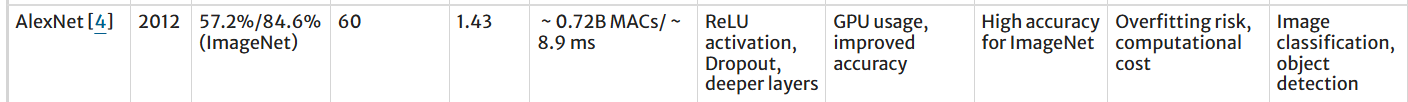



[AlexNet](https://papers.nips.cc/paper/4824-imagenet-classification-with-deep-convolutional-neural-networks.pdf) ganó la competición de Imagenet en 2012. Es una arquitectura similar a LeNet5 pero más profunda. Fue la primera red convolucional que ganó la competición, y también la primera en ser entrenada en GPUs.

![](https://miro.medium.com/fit/c/1838/551/1*arJJYgK-_7VcuKKX1TCKMA.png)

Implementadas en `Pytorch` podemos descargar redes convolucionales con el paquete `torchvision` (en varios paquetes) .

In [11]:
import torchvision
alexnet = torchvision.models.AlexNet()
alexnet

AlexNet(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(11, 11), stride=(4, 4), padding=(2, 2))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(64, 192, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(192, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (avgpool): AdaptiveAvgPool2d(output_size=(6, 6))
  (classifier): Sequential(
    (0): Dropout(p=0.5, inplace=False)
    (1): Linear(in_features=9216, out_features=4096, bias=True)
 

##Actividad
Analiza la siguiente celda de ejecución correspondiente a la arquitectura clásica AlexNet:
cual es el lote de imagenes de entrada canales, dimensiones? y porque su salida es el 1000 indica las lineas de codigo y que representa este numero?

In [12]:
output = alexnet(torch.randn(64, 3, 224, 224))
output.shape

torch.Size([64, 1000])

## VGG
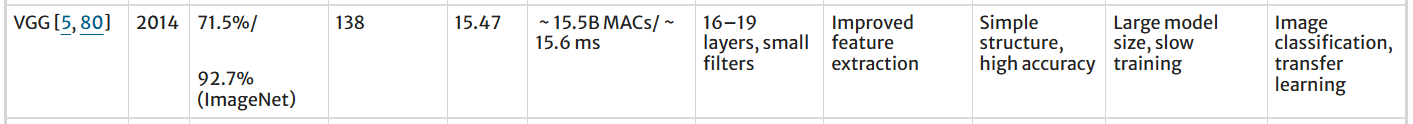



Si bien [VGG](https://arxiv.org/abs/1409.1556) no ganó, tuvo mucho éxito ya que sentó un precedente en el patrón del diseño de las redes convolucionales. Este patrón consiste en usar siempre capas convolucionales con filtros de 3x3, *stride* y *padding* 1 (manteniendo el tamaño de las entradas constante) y usar *max pool* para reducir a la mitad los mapas de características. Además, después de cada capa se dobla el número de filtros.

![](http://jesusutrera.com/articles/img/vgg_model.png)

In [13]:
vgg16 = torchvision.models.vgg16()
vgg16

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

In [14]:
output = vgg16(torch.randn(64, 3, 224, 224))
output.shape

torch.Size([64, 1000])

## Actividad modelos VGG
Investiga y define en codigo otros modelos de torchvision.models.vgg cuantos hay ya definidos?

## GoogLeNet
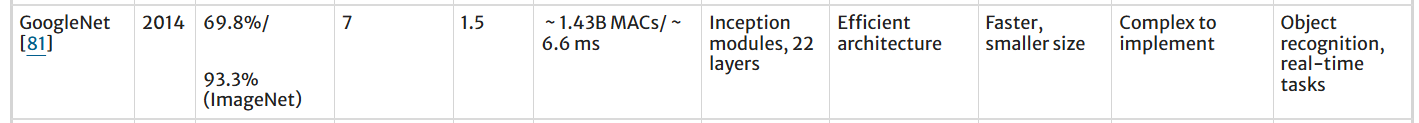



Ganadora de la edición de 2014, GoogLeNet es una red mucho más profunda (podemos empezar a ver la tendencia de que cuantas más capas, mejor resultados). Sus desarrolladores implementaron los módulos *inception*, los cuales aplican diferentes capas convolucionales, con diferentes tamaños de filtros, en paralelo sobre las mismas entradas y luego concatenan las salidas. Además, para poder entrenar esta red tan profunda, se llevan a cabo predicciones en diversas capas intermedias para poder tener gradientes fluyendo hacia las capas iniciales.

![](https://www.alanzucconi.com/wp-content/uploads/2015/07/googlenet-arch.png)

In [15]:
googlenet = torchvision.models.GoogLeNet()
googlenet

GoogLeNet(
  (conv1): BasicConv2d(
    (conv): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (maxpool1): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=True)
  (conv2): BasicConv2d(
    (conv): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (conv3): BasicConv2d(
    (conv): Conv2d(64, 192, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn): BatchNorm2d(192, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (maxpool2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=True)
  (inception3a): Inception(
    (branch1): BasicConv2d(
      (conv): Conv2d(192, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track

In [16]:
output = googlenet(torch.randn(64, 3, 224, 224))
output[0].shape

torch.Size([64, 1000])

## Actividad
¿Cuántos bloques Inception contiene en total la arquitectura y cómo están agrupados por letras (por ejemplo, a, b, etc.)?
¿Cuántas ramas convolucionales paralelas procesan la entrada simultáneamente dentro de ese único bloque? Agrega una imagen que lo ejemplifique
¿qué capa de pooling se utiliza en lugar del tradicional aplanamiento masivo (Flatten) que usaban redes como AlexNet o VGG? ¿Qué ventaja aporta esto al número total de parámetros del modelo?

#PARTE B
**Ajustes respecto a las arquitecturas originales:** las versiones originales de AlexNet y VGG16 fueron diseñadas para imágenes de 224×224 (ImageNet). Entrenarlas tal cual sobre CIFAR-10 (32×32) o reescalando cada imagen a 224×224 sería demasiado costoso. Por eso cada arquitectura se **adapta** aquí para trabajar directamente sobre 32×32 px, manteniendo su estructura conceptual (número y tipo de bloques, filtros, profundidad relativa) pero con canales/strides ajustados. Esto es intencional: la comparación de "capacidad versus eficiencia"

> 💡El dataset Imagenet contiene imágenes comunes descargadas de internet, y el objetivo es el de clasificar imágenes entre 1000 clases diferentes. Es por este motivo que verás que los diferentes modelos en `torchvision` tienen una última capa lineal con 1000 salidas.

## 1. Configuración e importaciones

In [17]:
import time
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
import pandas as pd

torch.manual_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo: {device}")


Dispositivo: cuda


## 2. Carga y preprocesamiento de CIFAR-10

Se usa CIFAR-10 (60,000 imágenes de 32×32 px a color, 10 clases) tal como indica el programa de la asignatura. Se separa un subconjunto de validación a partir del set de entrenamiento.

In [18]:
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616)),
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616)),
])

full_train_set = torchvision.datasets.CIFAR10(root="./data", train=True, download=True, transform=transform_train)
test_set = torchvision.datasets.CIFAR10(root="./data", train=False, download=True, transform=transform_test)

val_fraction = 0.1
val_size = int(len(full_train_set) * val_fraction)
train_size = len(full_train_set) - val_size
train_set, val_set = random_split(full_train_set, [train_size, val_size], generator=torch.Generator().manual_seed(42))

BATCH_SIZE = 128
train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_set, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader = DataLoader(test_set, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

classes = ("avión", "automóvil", "pájaro", "gato", "venado", "perro", "rana", "caballo", "barco", "camión")
print(f"Train: {len(train_set)} | Val: {len(val_set)} | Test: {len(test_set)}")


100%|██████████| 170M/170M [00:11<00:00, 14.8MB/s]


Train: 45000 | Val: 5000 | Test: 10000


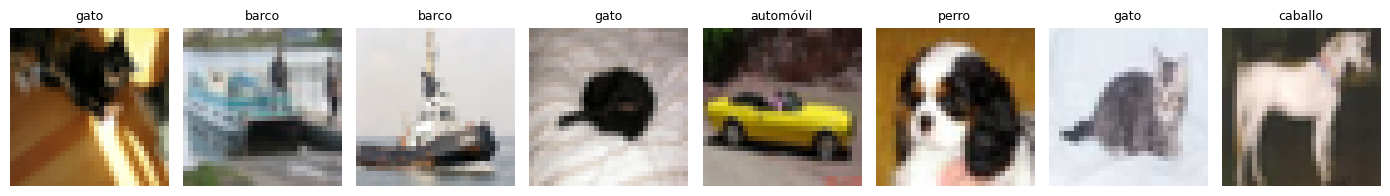

In [19]:
# Vista rápida de algunas imágenes del dataset
def imshow(img):
    img = img * torch.tensor([0.2470, 0.2435, 0.2616]).view(3,1,1) + torch.tensor([0.4914, 0.4822, 0.4465]).view(3,1,1)
    npimg = img.numpy()
    plt.imshow(npimg.transpose(1, 2, 0).clip(0, 1))

sample_loader = DataLoader(test_set, batch_size=8, shuffle=True)
images, labels = next(iter(sample_loader))
fig, axes = plt.subplots(1, 8, figsize=(14, 2))
for i, ax in enumerate(axes):
    ax.imshow((images[i] * torch.tensor([0.2470,0.2435,0.2616]).view(3,1,1) + torch.tensor([0.4914,0.4822,0.4465]).view(3,1,1)).permute(1,2,0).clip(0,1))
    ax.set_title(classes[labels[i]], fontsize=9)
    ax.axis("off")
plt.tight_layout()
plt.show()


## 3. Arquitecturas

Se implementan cuatro arquitecturas, cada una en su propia celda, con un breve comentario sobre su idea central y el ajuste realizado para CIFAR-10.

### 3.1 LeNet-5 (LeCun et al., 1998)

## Actividad
Escribe un parrafo resaltando las diferencias de la arquitectura adaptada vs original

In [20]:
class LeNet5(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 6, kernel_size=5, padding=2),   # 32x32 -> 32x32
            nn.Tanh(),
            nn.AvgPool2d(2),                              # -> 16x16
            nn.Conv2d(6, 16, kernel_size=5),               # -> 12x12
            nn.Tanh(),
            nn.AvgPool2d(2),                               # -> 6x6
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(16 * 6 * 6, 120), nn.Tanh(),
            nn.Linear(120, 84), nn.Tanh(),
            nn.Linear(84, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)


### 3.2 AlexNet adaptado (Krizhevsky et al., 2012)

## Actividad
Escribe un parrafo resaltando las diferencias de la arquitectura adaptada vs original

In [21]:
class AlexNetAdaptado(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, padding=1), nn.ReLU(inplace=True),
            nn.MaxPool2d(2),                                        # -> 16x16
            nn.Conv2d(64, 192, kernel_size=3, padding=1), nn.ReLU(inplace=True),
            nn.MaxPool2d(2),                                        # -> 8x8
            nn.Conv2d(192, 384, kernel_size=3, padding=1), nn.ReLU(inplace=True),
            nn.Conv2d(384, 256, kernel_size=3, padding=1), nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1), nn.ReLU(inplace=True),
            nn.MaxPool2d(2),                                        # -> 4x4
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.5),
            nn.Linear(256 * 4 * 4, 1024), nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(1024, 512), nn.ReLU(inplace=True),
            nn.Linear(512, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)


### 3.3 VGG16 adaptado (Simonyan & Zisserman, 2014)

## Actividad
Escribe un parrafo resaltando las diferencias de la arquitectura adaptada vs original

In [22]:
class VGGBlock(nn.Module):
    def __init__(self, in_channels, out_channels, num_convs):
        super().__init__()
        layers = []
        for i in range(num_convs):
            in_c = in_channels if i == 0 else out_channels
            layers += [nn.Conv2d(in_c, out_channels, kernel_size=3, padding=1), nn.ReLU(inplace=True)]
        layers.append(nn.MaxPool2d(2))
        self.block = nn.Sequential(*layers)

    def forward(self, x):
        return self.block(x)


class VGG16Adaptado(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            VGGBlock(3, 32, 2),     # 32x32 -> 16x16
            VGGBlock(32, 64, 2),    # -> 8x8
            VGGBlock(64, 128, 3),   # -> 4x4
            VGGBlock(128, 256, 3),  # -> 2x2
            VGGBlock(256, 256, 3),  # -> 1x1
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 1 * 1, 512), nn.ReLU(inplace=True), nn.Dropout(0.5),
            nn.Linear(512, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)


### 3.4 GoogLeNet mini (Szegedy et al., 2014)

## Actividad
Escribe un parrafo resaltando las diferencias de la arquitectura adaptada vs original

In [23]:
class InceptionBlock(nn.Module):
    def __init__(self, in_channels, ch1x1, ch3x3red, ch3x3, ch5x5red, ch5x5, pool_proj):
        super().__init__()
        self.branch1 = nn.Sequential(
            nn.Conv2d(in_channels, ch1x1, kernel_size=1), nn.ReLU(inplace=True))
        self.branch2 = nn.Sequential(
            nn.Conv2d(in_channels, ch3x3red, kernel_size=1), nn.ReLU(inplace=True),
            nn.Conv2d(ch3x3red, ch3x3, kernel_size=3, padding=1), nn.ReLU(inplace=True))
        self.branch3 = nn.Sequential(
            nn.Conv2d(in_channels, ch5x5red, kernel_size=1), nn.ReLU(inplace=True),
            nn.Conv2d(ch5x5red, ch5x5, kernel_size=5, padding=2), nn.ReLU(inplace=True))
        self.branch4 = nn.Sequential(
            nn.MaxPool2d(kernel_size=3, stride=1, padding=1),
            nn.Conv2d(in_channels, pool_proj, kernel_size=1), nn.ReLU(inplace=True))

    def forward(self, x):
        return torch.cat([self.branch1(x), self.branch2(x), self.branch3(x), self.branch4(x)], dim=1)


class GoogLeNetMini(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, padding=1), nn.ReLU(inplace=True),
            nn.MaxPool2d(2),                                    # -> 16x16
        )
        self.inception1 = InceptionBlock(64, 32, 32, 64, 8, 16, 16)     # out = 128
        self.inception2 = InceptionBlock(128, 64, 64, 96, 16, 32, 32)   # out = 224
        self.pool = nn.MaxPool2d(2)                                     # -> 8x8
        self.inception3 = InceptionBlock(224, 96, 64, 128, 16, 32, 32)  # out = 288
        self.global_pool = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Sequential(nn.Flatten(), nn.Dropout(0.4), nn.Linear(288, num_classes))

    def forward(self, x):
        x = self.stem(x)
        x = self.inception1(x)
        x = self.inception2(x)
        x = self.pool(x)
        x = self.inception3(x)
        x = self.global_pool(x)
        return self.classifier(x)


## 4. Funciones genéricas de entrenamiento y evaluación

Las mismas funciones se usan para las cuatro arquitecturas, para que la comparación final sea justa.

## Actividad
Define hiperparámetros de entrenamiento y optimizador

In [24]:
def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def train_model(model, train_loader, val_loader, epochs=8, lr=1e-3, name="modelo"):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

    start = time.time()
    for epoch in range(epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            out = model(x)
            loss = criterion(out, y)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * x.size(0)
            correct += (out.argmax(1) == y).sum().item()
            total += x.size(0)
        train_loss, train_acc = running_loss / total, correct / total

        model.eval()
        v_loss, v_correct, v_total = 0.0, 0, 0
        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(device), y.to(device)
                out = model(x)
                loss = criterion(out, y)
                v_loss += loss.item() * x.size(0)
                v_correct += (out.argmax(1) == y).sum().item()
                v_total += x.size(0)
        val_loss, val_acc = v_loss / v_total, v_correct / v_total

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        print(f"[{name}] Época {epoch+1}/{epochs} - "
              f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} "
              f"val_loss={val_loss:.4f} val_acc={val_acc:.4f}")

    elapsed = time.time() - start
    print(f"[{name}] Tiempo total de entrenamiento: {elapsed:.1f} s")
    return history, elapsed


def evaluate_test(model, test_loader):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for x, y in test_loader:
            x, y = x.to(device), y.to(device)
            out = model(x)
            correct += (out.argmax(1) == y).sum().item()
            total += x.size(0)
    return correct / total


## 5. Entrenamiento de las cuatro arquitecturas

`EPOCHS` Una buena práctica es configurar un bajo numero. Si el tiempo lo permite, se puede subir a 15–20 épocas para ver mejor las diferencias de convergencia.

In [25]:
EPOCHS = 5

modelos = {
    "LeNet-5": LeNet5(),
    "AlexNet (adaptado)": AlexNetAdaptado(),
    "GoogLeNet (mini)": GoogLeNetMini(),
    "VGG16 (adaptado)": VGG16Adaptado(),
}

historiales = {}
resultados = {}

for nombre, modelo in modelos.items():
    print(f"\n=== Entrenando {nombre} ===")
    n_params = count_params(modelo)
    print(f"Parámetros entrenables: {n_params:,}")
    hist, tiempo = train_model(modelo, train_loader, val_loader, epochs=EPOCHS, name=nombre)
    test_acc = evaluate_test(modelo, test_loader)
    print(f"[{nombre}] Accuracy en test: {test_acc:.4f}")

    historiales[nombre] = hist
    resultados[nombre] = {
        "parametros": n_params,
        "tiempo_entrenamiento_s": round(tiempo, 1),
        "val_acc_final": round(hist["val_acc"][-1], 4),
        "test_accuracy": round(test_acc, 4),
    }



=== Entrenando LeNet-5 ===
Parámetros entrenables: 83,126
[LeNet-5] Época 1/5 - train_loss=1.8714 train_acc=0.3272 val_loss=1.7642 val_acc=0.3746
[LeNet-5] Época 2/5 - train_loss=1.6737 train_acc=0.3980 val_loss=1.6265 val_acc=0.4150
[LeNet-5] Época 3/5 - train_loss=1.5595 train_acc=0.4374 val_loss=1.5236 val_acc=0.4572
[LeNet-5] Época 4/5 - train_loss=1.4913 train_acc=0.4591 val_loss=1.4632 val_acc=0.4682
[LeNet-5] Época 5/5 - train_loss=1.4498 train_acc=0.4770 val_loss=1.4745 val_acc=0.4634
[LeNet-5] Tiempo total de entrenamiento: 100.8 s
[LeNet-5] Accuracy en test: 0.5051

=== Entrenando AlexNet (adaptado) ===
Parámetros entrenables: 6,976,842
[AlexNet (adaptado)] Época 1/5 - train_loss=1.7686 train_acc=0.3256 val_loss=1.4321 val_acc=0.4680
[AlexNet (adaptado)] Época 2/5 - train_loss=1.3459 train_acc=0.5039 val_loss=1.2114 val_acc=0.5554
[AlexNet (adaptado)] Época 3/5 - train_loss=1.1421 train_acc=0.5878 val_loss=1.0118 val_acc=0.6382
[AlexNet (adaptado)] Época 4/5 - train_loss=1.0

## 6. Comparación de resultados

In [26]:
df_resultados = pd.DataFrame(resultados).T
df_resultados = df_resultados.sort_values("test_accuracy", ascending=False)
df_resultados


,parametros,tiempo_entrenamiento_s,val_acc_final,test_accuracy
AlexNet (adaptado),6976842.0,108.5,0.6978,0.7095
GoogLeNet (mini),256530.0,115.9,0.5942,0.5913
VGG16 (adaptado),3816874.0,110.2,0.5048,0.5061
LeNet-5,83126.0,100.8,0.4634,0.5051


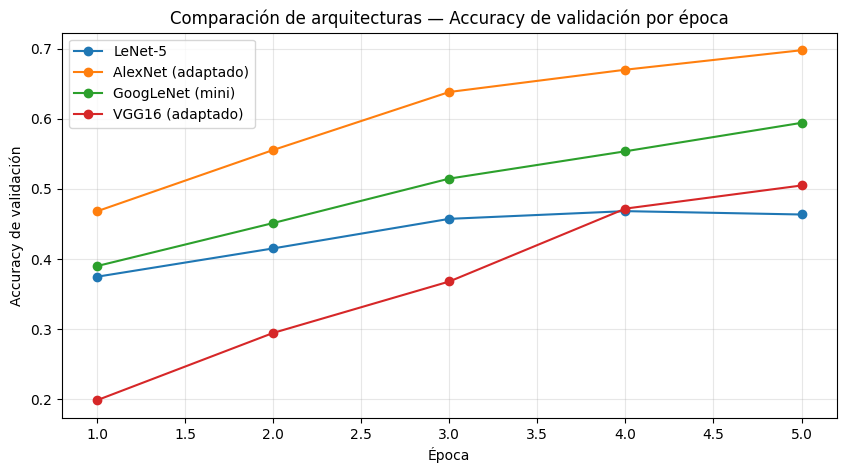

In [27]:
plt.figure(figsize=(10, 5))
for nombre, hist in historiales.items():
    plt.plot(range(1, EPOCHS + 1), hist["val_acc"], marker="o", label=nombre)
plt.xlabel("Época")
plt.ylabel("Accuracy de validación")
plt.title("Comparación de arquitecturas — Accuracy de validación por época")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


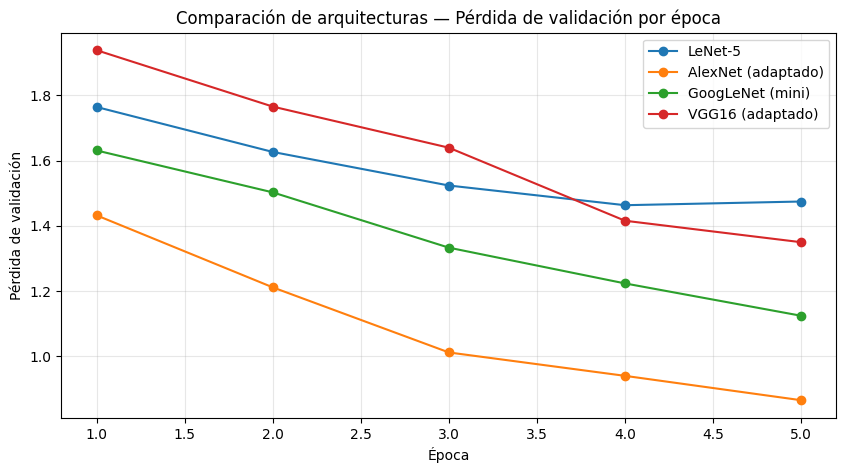

In [28]:
plt.figure(figsize=(10, 5))
for nombre, hist in historiales.items():
    plt.plot(range(1, EPOCHS + 1), hist["val_loss"], marker="o", label=nombre)
plt.xlabel("Época")
plt.ylabel("Pérdida de validación")
plt.title("Comparación de arquitecturas — Pérdida de validación por época")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


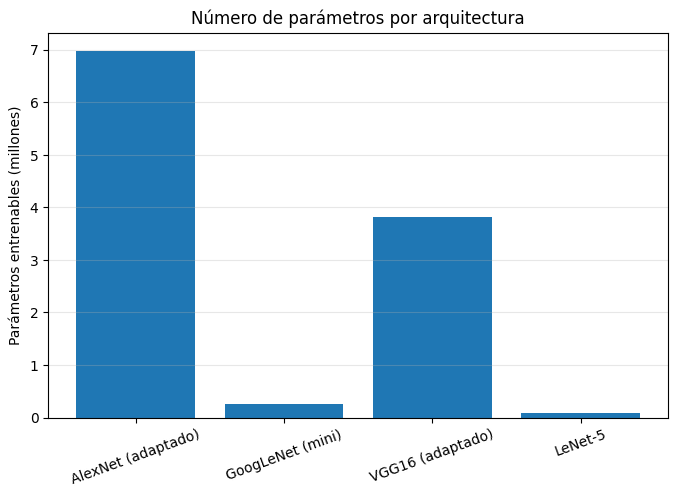

In [29]:
plt.figure(figsize=(8, 5))
plt.bar(df_resultados.index, df_resultados["parametros"] / 1e6)
plt.ylabel("Parámetros entrenables (millones)")
plt.title("Número de parámetros por arquitectura")
plt.xticks(rotation=20)
plt.grid(axis="y", alpha=0.3)
plt.show()


## 7. Preguntas de reflexión (para responder en la bitácora)

1. ¿Qué arquitectura obtuvo el mejor accuracy de test? ¿Es también la que más parámetros tiene o la más rápida de entrenar?
2. Compara LeNet-5 contra las otras tres: ¿qué tanto mejora el accuracy al aumentar la profundidad/capacidad del modelo, y a qué costo (tiempo, parámetros)?
3. GoogLeNet mini usa módulos Inception (varias convoluciones en paralelo) en vez de solo apilar capas como VGG16. ¿Se refleja esa diferencia de diseño en los resultados obtenidos aquí?
4. Si tuvieras que desplegar un modelo de clasificación de imágenes en un dispositivo con recursos limitados (por ejemplo, una cámara industrial), ¿cuál de estas cuatro arquitecturas elegirías y por qué? Relaciona tu respuesta con el criterio de "capacidad versus eficiencia".
5. ¿Qué esperarías que pasara con estas cuatro arquitecturas si se entrenaran 30 epocas? ¿Cambiaría?

## 8. Entrega

Subir este notebook ejecutado (con las salidas de las celdas visibles) al GitHub personal (publico) crear una carpeta para el curso, en subcarpeta correspondiente a la Unidad 1 / Práctica 3.

Subir en formato PDF a Classroom  + Anexar link de repositorio